## Import libraries

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import (
    cross_validate, cross_val_predict,
)
from sklearn.metrics import classification_report, confusion_matrix, make_scorer
from xgboost import XGBClassifier

## Load data

In [52]:
BINARY_TARGET = False
INCLUDE_GEX = True
CLASSIFIER = 'xgboost'

In [43]:

clinical_gex = pd.read_csv(
    '../dataset/created/clinical_gex.csv',
    low_memory=False
)
clinical_gex.columns = clinical_gex.columns.str.strip()

if BINARY_TARGET == True:
    clinical_gex = clinical_gex[clinical_gex['pfs_label'].isin([0,2])]
    clinical_gex['pfs_label'] = clinical_gex['pfs_label'].replace(2, 1)

y = clinical_gex['pfs_label']
x = clinical_gex.drop(['patientID', 'pfs_label', 'sample_id', 'source', 'brain_metastasis', 'source_right', 'pfs_label_right'], axis=1)

print(x.head())
print(f"\nTarget distribution:\n{y.value_counts().sort_index()}")

      sex  age AJCC_stage M_stage       LDH immunotherapy_treatment  \
0    male   26         IV     M1B  elevated                      no   
1  female   58         IV     M1A    normal                      no   
2    male   45         IV     M1A    normal                      no   
3    male   48       IIIC     NaN    normal                      no   
4    male   33         IV     M1C    normal                      no   

  pre_MAPKi_treatment  cobimetinib  dabrafenib  trametinib  ...    FBXO48  \
0                  no            0           0           0  ...  4.331667   
1                  no            0           0           0  ...  4.305585   
2                  no            0           0           0  ...  4.335151   
3                  no            1           0           0  ...  4.302483   
4                  no            1           0           0  ...  4.288154   

       SCD5    BCL11A      ALAD     EIF3F    SEMA3A    HIGD1B      CDO1  \
0  5.198299  5.026151  6.129603  8.

In [44]:
# Clinical columns that need preprocessing
clinical_ordinal_col = ['M_stage']
clinical_categorical_cols = [
    'sex', 'AJCC_stage', 'LDH',
    'immunotherapy_treatment', 'pre_MAPKi_treatment'
]
clinical_numeric_col = ['age']

drug_braf_cols = [
    'cobimetinib', 'trametinib', 'dabrafenib', 'vemurafenib',
    'C195W', 'K601I', 'R558Q', 'MND', 'V600E', 'V600K', 'V600R'
]

# Gene expression columns (everything else)
all_non_gex = (
    clinical_ordinal_col + clinical_categorical_cols +
    clinical_numeric_col + drug_braf_cols
)
gex_cols = [c for c in x.columns if c not in all_non_gex]

print(f"\nClinical features: {len(clinical_ordinal_col) + len(clinical_categorical_cols) + len(clinical_numeric_col)}")
print(f"Drug/BRAF dummies: {len(drug_braf_cols)}")
print(f"Gene expression features: {len(gex_cols)}")


Clinical features: 7
Drug/BRAF dummies: 11
Gene expression features: 113


## Preprocessing pipeline

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

if INCLUDE_GEX == True:
    remainder='passthrough'
else:
    remainder='drop'

clinical_preprocessor = ColumnTransformer(
    transformers=[
        ('m_stage', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(
                categories=[['M1A', 'M1B', 'M1C']],
                handle_unknown='use_encoded_value',
                unknown_value=np.nan
            )),
        ]), clinical_ordinal_col),

        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
        ]), clinical_categorical_cols),

        ('age', SimpleImputer(strategy='median'), clinical_numeric_col),
        ('drug_braf', 'passthrough', drug_braf_cols)
    ],
    remainder=remainder # gene expressions
)

x_processed = clinical_preprocessor.fit_transform(x)
x_processed = pd.DataFrame(x_processed, columns=clinical_preprocessor.get_feature_names_out())
x_processed

,m_stage__M_stage,categorical__sex_female,categorical__sex_male,categorical__AJCC_stage_IIIC,categorical__AJCC_stage_IV,categorical__LDH_elevated,categorical__LDH_normal,categorical__immunotherapy_treatment_no,categorical__pre_MAPKi_treatment_no,age__age,...,remainder__FBXO48,remainder__SCD5,remainder__BCL11A,remainder__ALAD,remainder__EIF3F,remainder__SEMA3A,remainder__HIGD1B,remainder__CDO1,remainder__FGF13,remainder__CKAP5
0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,26.0,...,4.331667,5.198299,5.026151,6.129603,8.097423,4.964542,4.321008,5.059288,5.314315,7.235586
1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,58.0,...,4.305585,5.235705,4.981705,6.702388,9.007194,4.470933,4.334177,5.050975,5.253968,7.597721
2,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,45.0,...,4.335151,5.269274,5.031074,6.153059,8.238361,4.528337,4.322683,5.049908,5.753911,7.362745
3,2.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,48.0,...,4.302483,5.241209,5.008037,6.220578,8.337190,4.651761,4.339989,5.099321,5.272151,7.003382
4,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,33.0,...,4.288154,5.189359,4.974259,6.608969,8.789412,5.161365,4.337075,5.062783,5.331733,7.562456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,62.0,...,4.250587,4.979063,5.071905,5.835589,8.368176,4.950745,4.300619,4.994787,5.011248,6.884087
121,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,49.0,...,4.276674,5.442084,5.039470,6.273037,8.475832,4.758133,4.178416,4.956155,5.667610,8.215198
122,2.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,68.0,...,4.292633,5.017959,5.160034,6.468576,8.349389,4.810269,4.271833,5.019694,5.144334,7.834134
123,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,72.0,...,4.298791,4.985050,5.090495,6.535787,8.455277,4.812004,4.198100,4.985225,5.672139,7.772773


In [ ]:
x = x_processed.copy()

## Hyperparams tuning

In [47]:
lr_clf = LogisticRegression(
    solver='saga',
    l1_ratio=0.5,
    C=0.1,
    class_weight='balanced',
    max_iter=5000,
    random_state=42
)

if BINARY_TARGET == True:
    xgboost_clf = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
    )
else:
    xgboost_clf = XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss',
        random_state=42,
    )

In [48]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
    }

    xgboost_clf.set_params(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(xgboost_clf, x, y, cv=cv, scoring='f1_macro', n_jobs=-1)

    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200)

print("Best params:", study.best_params)
print("Best CV AUC:", study.best_value)

[I 2026-04-08 14:43:50,136] A new study created in memory with name: no-name-705e5181-284a-42ea-9b65-fac679d70f59
[I 2026-04-08 14:43:50,360] Trial 0 finished with value: 0.6494491715181371 and parameters: {'n_estimators': 318, 'max_depth': 4, 'learning_rate': 0.02374687886731795, 'subsample': 0.7654668869234652, 'colsample_bytree': 0.5181953056039559, 'reg_alpha': 0.02988269282087296, 'reg_lambda': 0.01947790523708981, 'min_child_weight': 5, 'gamma': 0.8454979077858027}. Best is trial 0 with value: 0.6494491715181371.
[I 2026-04-08 14:43:50,460] Trial 1 finished with value: 0.5153388223976458 and parameters: {'n_estimators': 121, 'max_depth': 3, 'learning_rate': 0.016905749223326445, 'subsample': 0.5531893832545354, 'colsample_bytree': 0.8320251582480902, 'reg_alpha': 0.039926429060570236, 'reg_lambda': 1.6148554695460706, 'min_child_weight': 7, 'gamma': 0.8476047598392167}. Best is trial 0 with value: 0.6494491715181371.
[I 2026-04-08 14:43:50,572] Trial 2 finished with value: 0.2715

Best params: {'n_estimators': 261, 'max_depth': 2, 'learning_rate': 0.058101384981319656, 'subsample': 0.8464815694697522, 'colsample_bytree': 0.9685092725064606, 'reg_alpha': 0.3333467159967294, 'reg_lambda': 0.10627850108863014, 'min_child_weight': 2, 'gamma': 0.7547946163756986}
Best CV AUC: 0.7101214044679006


In [49]:
def objective_lr(trial):
    params = {
        'C': trial.suggest_float('C', 0.001, 10.0, log=True),
        'l1_ratio': trial.suggest_float('l1_ratio', 0.0, 1.0),
    }

    lr_clf.set_params(**params)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(lr_clf, x, y, cv=cv, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=100)

print("Best params:", study_lr.best_params)
print("Best CV AUC:", study_lr.best_value)

[I 2026-04-08 14:44:44,314] A new study created in memory with name: no-name-f27f5b14-4dab-4f77-92d1-62d7519a99f4
[I 2026-04-08 14:44:45,379] Trial 0 finished with value: 0.6241361108027774 and parameters: {'C': 0.9211753429648778, 'l1_ratio': 0.989354360199622}. Best is trial 0 with value: 0.6241361108027774.
[I 2026-04-08 14:44:46,325] Trial 1 finished with value: 0.667696634520164 and parameters: {'C': 0.47842339455220867, 'l1_ratio': 0.9646387042696293}. Best is trial 1 with value: 0.667696634520164.
[I 2026-04-08 14:44:46,845] Trial 2 finished with value: 0.24730520788312327 and parameters: {'C': 0.003410922458367202, 'l1_ratio': 0.42852423174273513}. Best is trial 1 with value: 0.667696634520164.
[I 2026-04-08 14:44:47,386] Trial 3 finished with value: 0.29933920702238553 and parameters: {'C': 0.007888502196300957, 'l1_ratio': 0.5285823308753131}. Best is trial 1 with value: 0.667696634520164.
[I 2026-04-08 14:44:48,211] Trial 4 finished with value: 0.6440001356668024 and paramet

Best params: {'C': 0.3301507852696638, 'l1_ratio': 0.8793404639071619}
Best CV AUC: 0.6774874363109656


## Run models

Test ROC-AUC (OVO) : 0.836 ± 0.058
Test Macro F1      : 0.710 ± 0.101
Train ROC-AUC (OVO): 1.000 ± 0.000
Train Macro F1     : 0.996 ± 0.005


              precision    recall  f1-score   support

  Short resp       0.73      0.92      0.81        66
Intermediate       0.84      0.59      0.70        27
   Long resp       0.77      0.53      0.63        32

    accuracy                           0.75       125
   macro avg       0.78      0.68      0.71       125
weighted avg       0.76      0.75      0.74       125



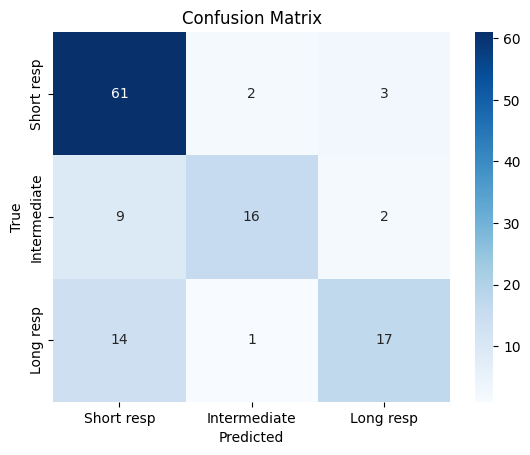

In [53]:
from sklearn.ensemble import VotingClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgboost_clf.set_params(**study.best_params)
lr_clf.set_params(**study_lr.best_params)

lr_pipe = Pipeline([('scaler', StandardScaler()), ('clf', lr_clf)])

voting_clf = VotingClassifier(
    estimators=[('xgb', xgboost_clf), ('lr', lr_pipe)],
    voting='soft',
    weights=[1, 1]
)

if CLASSIFIER == 'xgboost':
    clf = xgboost_clf
elif CLASSIFIER == 'lr':
    clf = lr_pipe
elif CLASSIFIER == 'voting':
    clf = voting_clf
else:
    raise ValueError('Classifier is not specified')

results = cross_validate(
    clf, x, y,
    cv=cv,
    scoring=['roc_auc_ovo', 'f1_macro'],
    return_train_score=True,
    n_jobs=-1
)
y_pred = cross_val_predict(
    clf, x, y, cv=cv,
    n_jobs=-1
)

if BINARY_TARGET == True:
    target_names = ['Short resp', 'Long resp']
else:
    target_names = ['Short resp', 'Intermediate', 'Long resp']

print(f"Test ROC-AUC (OVO) : {results['test_roc_auc_ovo'].mean():.3f} ± {results['test_roc_auc_ovo'].std():.3f}")
print(f"Test Macro F1      : {results['test_f1_macro'].mean():.3f} ± {results['test_f1_macro'].std():.3f}")
print(f"Train ROC-AUC (OVO): {results['train_roc_auc_ovo'].mean():.3f} ± {results['train_roc_auc_ovo'].std():.3f}")
print(f"Train Macro F1     : {results['train_f1_macro'].mean():.3f} ± {results['train_f1_macro'].std():.3f}")

print("\n")
print(classification_report(
    y, y_pred,
    target_names=target_names
))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names,
            yticklabels=target_names,
            cmap='Blues')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

## Explanability

Predicted class: 0


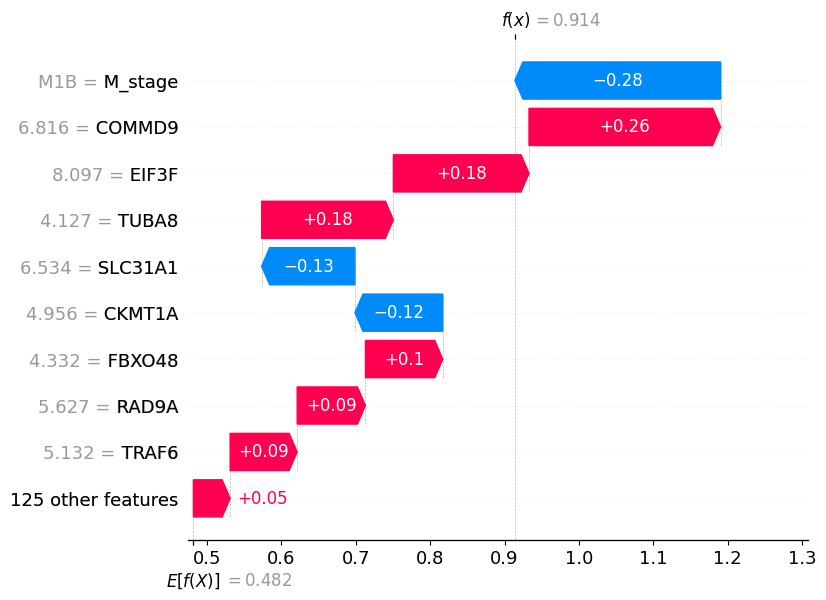

In [70]:
import shap

model = xgboost_clf.fit(x, y)
explainer = shap.TreeExplainer(model)
shap_values = explainer(x)

predicted_class = int(model.predict(x)[0])
print(f'Predicted class: {predicted_class}')

x_display = x.copy()

# Column is already renamed to M_stage
m_stage_map = {0: "M1A", 1: "M1B", 2: "M1C"}
x_display["M_stage"] = x_display["M_stage"].map(m_stage_map)

sv = shap.Explanation(
    values=shap_values.values[0, :, predicted_class],
    base_values=float(shap_values.base_values[0, predicted_class]),
    data=x_display.iloc[0].values,
    feature_names=x_display.columns.tolist()
)

shap.plots.waterfall(sv)
plt.show()